<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [4]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else: 
    device = 'cpu'

print(f"Current Device: {device}")


2.5.0
Current Device: mps


1. What are 3 areas in industry where computer vision is currently being used?
2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 
3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.
4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).
* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [7]:
import os

# Get the current working directory
current_directory = os.getcwd()
current_directory

'/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning'

In [8]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.MNIST(root= current_directory,
                               train= True,
                               download= True,
                               transform= ToTensor(), 
                               target_transform= None)


test_dataset = datasets.MNIST(root= current_directory,
                               train= False,
                               download= True,
                               transform= ToTensor(), 
                               target_transform= None)

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1006)>



100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw/train-images-idx3-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1006)>



100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw/train-labels-idx1-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1006)>



100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw/t10k-images-idx3-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1006)>



100.0%

Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/MNIST/raw



## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [63]:
image_sample1, label_sample1 = train_dataset[0]
image_sample1, label_sample1 

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [13]:
len(train_dataset.data), len(train_dataset.targets), len(test_dataset.data), len(test_dataset.targets)

(60000, 60000, 10000, 10000)

In [17]:
class_name = train_dataset.classes
class_name

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

(-0.5, 27.5, 27.5, -0.5)

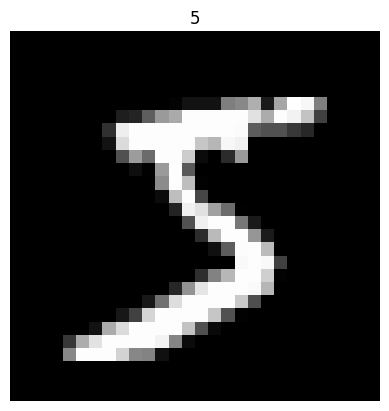

In [19]:
import matplotlib.pyplot as plt
plt.imshow(image_sample1.squeeze(), cmap= 'gray')
plt.title(label_sample1)
plt.axis("off")

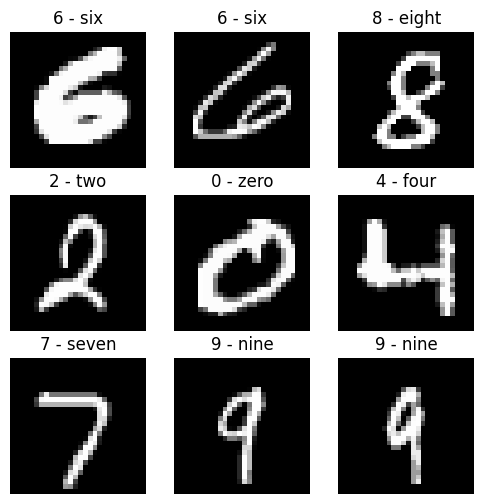

In [23]:
torch.manual_seed(42)
fig = plt.figure(figsize= (6, 6))
rows, cols = 3, 3
for i in range(1, rows*cols +1):
    random_idx = torch.randint(0, len(train_dataset), size = [1]).item()
    img, label = train_dataset[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_name[label])
    plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [25]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_dataset, 
                              batch_size= BATCH_SIZE,
                              shuffle=True)


test_dataloader = DataLoader(test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x163661a90>, <torch.utils.data.dataloader.DataLoader object at 0x163586a90>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [27]:
from torch import nn

In [53]:
class MNISTClassifier(nn.Module):
    def __init__(self, input_shape: int, hidden_layer: int, output_shape: int):
        super().__init__()
        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_layer, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_layer, out_channels = hidden_layer, kernel_size = 3, stride = 1, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2)
        )
        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_layer, 
                      out_channels= hidden_layer, 
                      kernel_size= 3, 
                      stride= 1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_layer, 
                      out_channels= hidden_layer, 
                      kernel_size= 3, 
                      stride= 1, 
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_layer*7*7, out_features= output_shape)
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.classifier(x)
        return x

In [54]:
model = MNISTClassifier(input_shape = 1, 
                        hidden_layer = 10,  
                        output_shape=10).to(device)
model

MNISTClassifier(
  (conv_layer1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [55]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

### On APPLE GPU

In [56]:
%%time
from tqdm.auto import tqdm 

EPOCHS = 5

for epoch in tqdm(range(EPOCHS)):
    train_loss = 0
    model.train()

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        # Foward pass
        y_logits = model(X)
        # Calculate Loss
        loss = loss_fn(y_logits, y)
        train_loss += loss

        # Zero grad
        optimizer.zero_grad()

        # Back propagation
        loss.backward()

        # Optimize the step
        optimizer.step()
    
    train_loss /= len(train_dataloader)

    # Testing loop
    test_loss_total = 0
    model.eval()
    with torch.inference_mode():
        for batch, (X_test, y_test) in enumerate(test_dataloader):
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_y_logits = model(X_test)
            test_loss = loss_fn(test_y_logits, y_test)
            test_loss_total += test_loss
        
        test_loss_total /= len(test_dataloader)

    print(f"EPOCH: {epoch}| Loss: {train_loss:.3f} | Test Loss: {test_loss_total:.3f}")

 20%|██        | 1/5 [00:07<00:29,  7.28s/it]

EPOCH: 0| Loss: 0.294 | Test Loss: 0.074


 40%|████      | 2/5 [00:14<00:22,  7.41s/it]

EPOCH: 1| Loss: 0.078 | Test Loss: 0.059


 60%|██████    | 3/5 [00:22<00:14,  7.40s/it]

EPOCH: 2| Loss: 0.061 | Test Loss: 0.055


 80%|████████  | 4/5 [00:29<00:07,  7.48s/it]

EPOCH: 3| Loss: 0.053 | Test Loss: 0.044


100%|██████████| 5/5 [00:37<00:00,  7.48s/it]

EPOCH: 4| Loss: 0.046 | Test Loss: 0.052
CPU times: user 28.8 s, sys: 4.37 s, total: 33.1 s
Wall time: 37.4 s


#### On CPU

In [57]:
model_cpu = MNISTClassifier(input_shape = 1, 
                        hidden_layer = 10,  
                        output_shape=10).to('cpu')
model_cpu

MNISTClassifier(
  (conv_layer1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [59]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_cpu.parameters(), lr=0.1)

In [60]:
%%time
from tqdm.auto import tqdm

EPOCHS = 5

for epoch in tqdm(range(EPOCHS)):
    train_loss = 0
    model_cpu.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to('cpu'), y.to('cpu')
        # Forward Pass
        y_logits = model_cpu(X)
        # Calculate the loss
        loss = loss_fn(y_logits, y)
        train_loss += loss
        #Optimize the zero grad
        optimizer.zero_grad()
        # Loss backward 
        loss.backward()
        # Optimize the step
        optimizer.step()
    train_loss /= len(train_dataloader)

    # Test Loop
    test_loss_total = 0
    model_cpu.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataloader):
            X_test, y_test = X.to('cpu'), y.to('cpu')
            test_y_logits = model_cpu(X_test)
            test_loss = loss_fn(test_y_logits, y_test)
            test_loss_total += test_loss
        
        test_loss_total /= len(test_dataloader)

    print(f'EPOCH: {epoch} | Loss: {train_loss:.3f} | Test Loss: {test_loss_total:.3f}')


 20%|██        | 1/5 [00:27<01:48, 27.00s/it]

EPOCH: 0 | Loss: 0.240 | Test Loss: 0.078


 40%|████      | 2/5 [00:54<01:22, 27.49s/it]

EPOCH: 1 | Loss: 0.072 | Test Loss: 0.051


 60%|██████    | 3/5 [01:19<00:52, 26.22s/it]

EPOCH: 2 | Loss: 0.057 | Test Loss: 0.048


 80%|████████  | 4/5 [01:47<00:26, 26.79s/it]

EPOCH: 3 | Loss: 0.048 | Test Loss: 0.049


100%|██████████| 5/5 [02:20<00:00, 28.16s/it]

EPOCH: 4 | Loss: 0.043 | Test Loss: 0.054
CPU times: user 7min 53s, sys: 1min 2s, total: 8min 55s
Wall time: 2min 20s


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

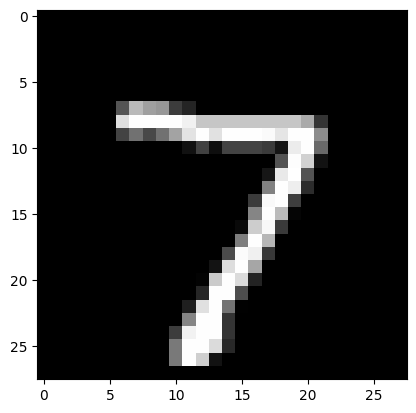

In [61]:
# test_dataset 為 image + label 的 tuple組合 
plt.imshow(test_dataset[0][0].squeeze(), cmap="gray")

In [80]:
# Obtain logits
pred_logits_test_sample1 = model(test_dataset[0][0].unsqueeze(dim = 0).to(device))
# model 會接收 shape為[batch, c, w, h] 的輸入， 所以要先進行unsqueeze
# Obtain pred probabilities
pred_prob_test_sample1 = torch.softmax(pred_logits_test_sample1, dim = 1)

pred_label_test_sample1 = torch.argmax(pred_prob_test_sample1, dim = 1)

pred_label_test_sample1


tensor([7], device='mps:0')

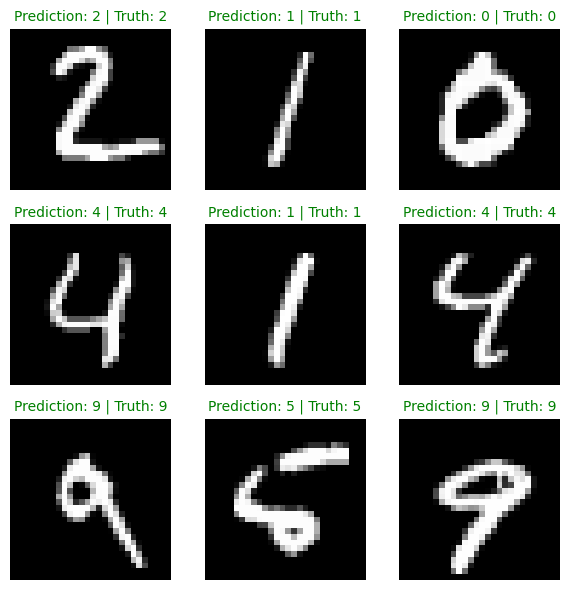

In [83]:
fig2 = plt.figure(figsize=(6, 6))  # Set the figure size
rows, cols = 3, 3  # Define the grid dimensions
for i in range(1, rows*cols + 1):
    ax = fig2.add_subplot(rows, cols, i)  # Add a subplot in a grid of 3x3
    ax.imshow(test_dataset[i][0].squeeze(), cmap="gray")  # Display the image (grayscale)
    
    # Get model predictions
    pred_logits_test_sample = model(test_dataset[i][0].unsqueeze(dim=0).to(device))
    pred_label_test_sample = torch.argmax(pred_logits_test_sample, dim=1)
    
    title = f"Prediction: {pred_label_test_sample.cpu().item()} | Truth: {test_dataset[i][1]}"
    # Set the title with predicted and true label
    ax.axis('off')
      # Check for equality and change title colour accordingly
    if pred_label_test_sample.cpu().item() == test_dataset[i][1]:
        plt.title(title, fontsize=10, c="g") # green text if correct
    else:
        plt.title(title, fontsize=10, c="r") # red text if wron
plt.tight_layout()  # Automatically adjust subplot parameters to give space between plots
plt.show()  # Display the figure

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [86]:
# Make prediction using trained model
from tqdm.auto import tqdm
model.eval()
y_preds = []
with torch.inference_mode():
    for batch, (X_test, y_test) in tqdm(enumerate(test_dataloader)):
        X_test, y_test = X_test.to(device), y_test.to(device)
        pred_logits = model(X_test)
        pred_label = torch.argmax(pred_logits, dim = 1)
        y_preds.append(pred_label)
    y_preds=torch.cat(y_preds).cpu()

313it [00:00, 553.66it/s]


In [89]:
len(y_preds)

10000

In [92]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Initiate a Confusion Matrix
confmat = ConfusionMatrix(task = 'multiclass', num_classes= len(class_name))
confmat_tensor = confmat(preds = y_preds,
                         target = test_dataset.targets)

confmat_tensor

tensor([[ 973,    1,    1,    0,    0,    0,    1,    2,    1,    1],
        [   0, 1135,    0,    0,    0,    0,    0,    0,    0,    0],
        [   2,    7, 1017,    0,    0,    0,    0,    5,    1,    0],
        [   0,    0,    7,  987,    0,    5,    0,    6,    2,    3],
        [   1,    1,    3,    0,  975,    0,    0,    0,    0,    2],
        [   3,    1,    0,    3,    0,  877,    4,    2,    1,    1],
        [   4,    4,    0,    0,    3,    1,  946,    0,    0,    0],
        [   0,    6,    3,    0,    0,    0,    0, 1015,    1,    3],
        [   7,    5,    2,    0,    9,    2,    7,    3,  928,   11],
        [   0,    6,    1,    0,   10,    3,    0,    6,    0,  983]])

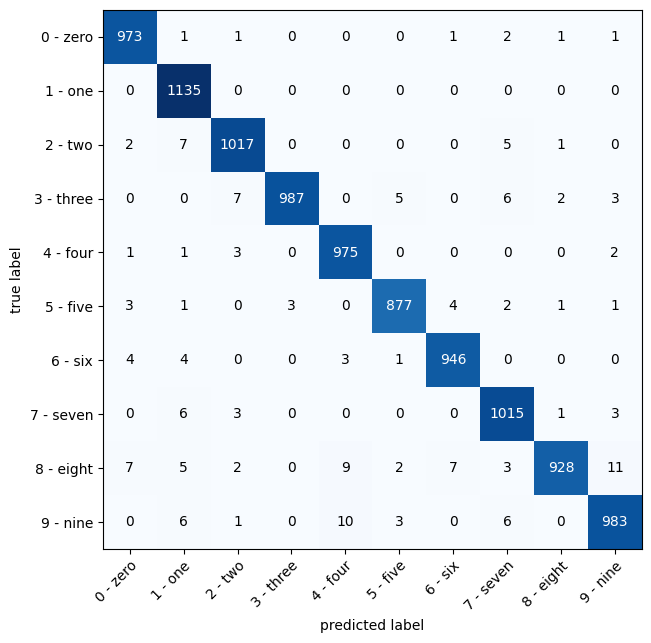

In [93]:
# Neat CM plot by mlxtend
fix, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_name,
    figsize=(10, 7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [94]:
fashion_train_dataset = datasets.FashionMNIST(root= current_directory,
                               train= True,
                               download= True,
                               transform= ToTensor(), 
                               target_transform= None)


fashion_test_dataset = datasets.FashionMNIST(root= current_directory,
                               train= False,
                               download= True,
                               transform= ToTensor(), 
                               target_transform= None)

100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw/train-images-idx3-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw



100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw/train-labels-idx1-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw



100.0%


Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw



100.0%

Extracting /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/FashionMNIST/raw



In [95]:
len(fashion_train_dataset), len(fashion_test_dataset)

(60000, 10000)

In [96]:
fashion_class_name = fashion_train_dataset.classes
fashion_class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [97]:
fashion_sample1_image, fashion_sample1_label = fashion_train_dataset[0]

(-0.5, 27.5, 27.5, -0.5)

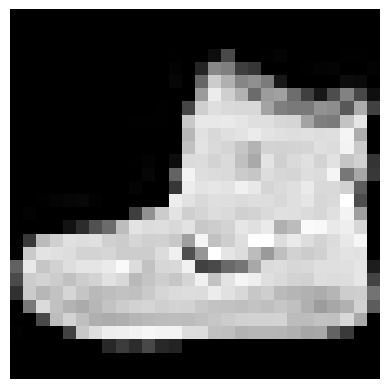

In [99]:
plt.imshow(fashion_sample1_image.squeeze(), cmap= 'gray')
plt.axis('off')

In [108]:
BATCH_SIZE = 32

fashion_train_dataloader = DataLoader(fashion_train_dataset, 
                              batch_size= BATCH_SIZE,
                              shuffle=True)


fashion_test_dataloader = DataLoader(fashion_test_dataset,
                                     batch_size = BATCH_SIZE,
                                     shuffle = False)

print(f'The train set contains {len(fashion_train_dataloader)} batches of {BATCH_SIZE}')
print(f'The test set contains {len(fashion_test_dataloader)} batches of {BATCH_SIZE}')

The train set contains 1875 batches of 32
The test set contains 313 batches of 32


In [112]:
model2 = MNISTClassifier(input_shape= 1,
                         hidden_layer= 10, 
                         output_shape= 10).to(device)
model2

MNISTClassifier(
  (conv_layer1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [113]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model2.parameters(), 
                            lr = 0.01)

In [114]:
from tqdm.auto import tqdm
from torchmetrics import Accuracy

acc_fn = Accuracy(task= 'multiclass', num_classes= len(fashion_class_name)).to(device)

EPOCHS = 5

for epoch in tqdm(range(EPOCHS)):
    train_loss, test_loss_total = 0, 0
    train_acc, test_acc = 0, 0

    model2.train()
    for batch, (X, y) in enumerate(fashion_train_dataloader):
        X, y = X.to(device), y.to(device)
        
        pred_logits = model2(X)

        loss = loss_fn(pred_logits, y)
        train_loss += loss
        train_acc += acc_fn(pred_logits, y) 

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    
    train_loss /= len(fashion_train_dataloader) 
    train_acc /= len(fashion_train_dataloader)

    model2.eval()
    with torch.inference_mode():
        for batch, (X_test, y_test) in enumerate(fashion_test_dataloader):
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred_logits = model2(X_test)
            loss = loss_fn(test_pred_logits, y_test)
            acc  = acc_fn(test_pred_logits, y_test)

            test_loss_total += loss
            test_acc += acc

        test_loss_total /= len(fashion_test_dataloader)
        test_acc /= len(fashion_test_dataloader)

    print(f'EPOCH: {epoch} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f} | Test Loss: {test_loss_total:.3f} | Test Acc: {test_acc:.2f}')

 20%|██        | 1/5 [00:09<00:39,  9.87s/it]

EPOCH: 0 | Train Loss: 2.301 | Train Acc: 0.12 | Test Loss: 2.295 | Test Acc: 0.15


 40%|████      | 2/5 [00:19<00:29,  9.76s/it]

EPOCH: 1 | Train Loss: 1.095 | Train Acc: 0.63 | Test Loss: 0.605 | Test Acc: 0.79


 60%|██████    | 3/5 [00:29<00:19,  9.73s/it]

EPOCH: 2 | Train Loss: 0.519 | Train Acc: 0.81 | Test Loss: 0.511 | Test Acc: 0.82


 80%|████████  | 4/5 [00:38<00:09,  9.68s/it]

EPOCH: 3 | Train Loss: 0.439 | Train Acc: 0.84 | Test Loss: 0.439 | Test Acc: 0.85


100%|██████████| 5/5 [00:48<00:00,  9.71s/it]

EPOCH: 4 | Train Loss: 0.401 | Train Acc: 0.86 | Test Loss: 0.400 | Test Acc: 0.86


In [120]:
## Making Predictions
test_pred_model2 =[]

model2.eval()
with torch.inference_mode():
    for X_test, y_test in tqdm(fashion_test_dataloader):
        X_test, y_test = X_test.to(device), y_test.to(device)
        test_pred_logits = model2(X_test)
        test_pred_label = torch.argmax(test_pred_logits, dim = 1)
        test_pred_model2.append(test_pred_label)   # 將多個預測出來的tensor 放進list中

test_pred_model2 = torch.cat(test_pred_model2).cpu() # 將多個預測出來的tensor合併成一個大Tensor
test_pred_model2

100%|██████████| 313/313 [00:00<00:00, 571.34it/s]


tensor([9, 2, 1,  ..., 8, 1, 5])

In [123]:
# How many wrong predictions
import numpy as np
wrong_pred_indexes = np.where(test_pred_model2 != fashion_test_dataset.targets)[0]
len(wrong_pred_indexes)

1410

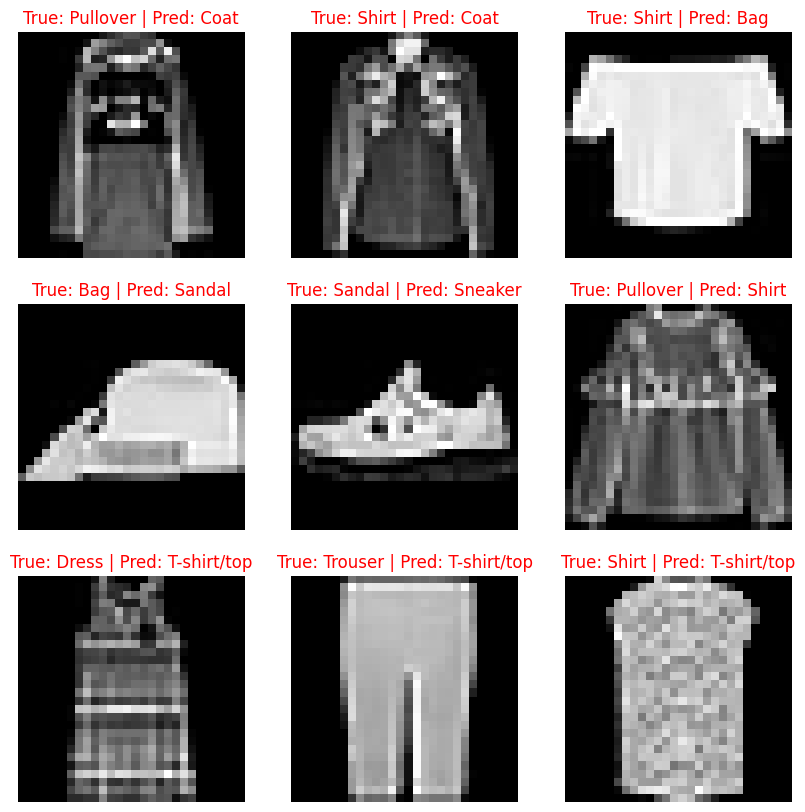

In [135]:
import random
random_selection = random.sample(list(wrong_pred_indexes), k=9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_selection):
  # Get true and pred labels
  true_label = fashion_class_name[fashion_test_dataset[idx][1]]
  pred_label = fashion_class_name[test_pred_model2[idx]]

  # Plot the wrong prediction with its original label
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_test_dataset[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")
  plt.axis(False);